### Get Dataset

In [1]:
import pandas as pd 
import re
import matplotlib.pyplot as plt
from sklearn.preprocessing import MultiLabelBinarizer

pd.set_option('display.max_columns', None)

In [2]:
dsqi = pd.read_csv('dataset_multiintent.csv', encoding='latin-1') # dsqi = dataset question intent
dsqi.info()

<class 'pandas.DataFrame'>
RangeIndex: 351 entries, 0 to 350
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   question  351 non-null    str  
 1   Intent    348 non-null    str  
dtypes: str(2)
memory usage: 5.6 KB


In [3]:
dsqi.head()

,question,Intent
0,"Jujur, saya merasa cukup cemas sebelum datang ...",Perasaan Takut dan Kecemasan; Perasaan Sebelum...
1,"Saya merasa agak gugup, Kak. Saya tidak tahu b...",Perasaan Takut dan Kecemasan; Perasaan Sebelum...
2,"Saya merasa baik-baik saja, Kak. Awalnya saya ...",Rasa Syukur dan Apresiasi; Reaksi Terkejut dan...
3,"Saya merasa agak cemas, Kak. Tapi saya ingin m...",Perasaan Sebelum Menghadapi Kejadian
4,"Saya merasa... biasa saja, tapi kadang saya me...",Perasaan Sedih dan Kehilangan


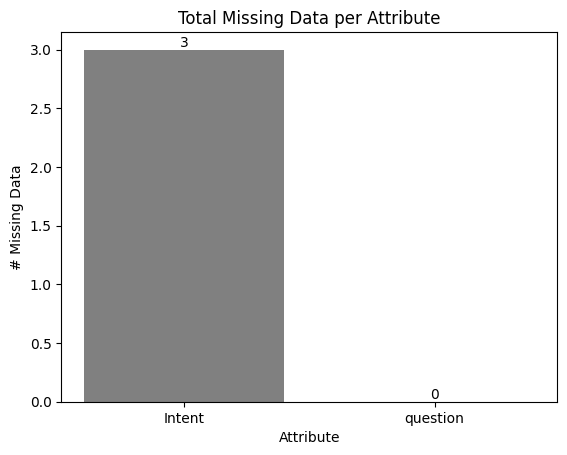

In [4]:
# Check Missing Values

df_nan = dsqi.isna().sum().reset_index().rename(columns={'index':'Column',0:'Total_NaN'}).sort_values(by='Total_NaN', ascending=False)
plt.bar(x=df_nan['Column'], height=df_nan['Total_NaN'], color='grey')
for i, v in enumerate(df_nan['Total_NaN']):
    plt.text(i, v, str(v), ha='center', va='bottom')
plt.title("Total Missing Data per Attribute")
plt.ylabel('# Missing Data')
plt.xlabel('Attribute')
plt.show()

In [5]:
# checking missing data in attribute `intent`
print(f"Total missing data: {dsqi[dsqi['Intent'].isna()].shape[0]}\n-----------------")
dsqi[dsqi['Intent'].isna()].head()

Total missing data: 3
-----------------


,question,Intent
292,Saya ingin fokus kuliah dan memperbaiki diri. ...,NaN
296,"Aku mau coba, tapi gimana caranya?",NaN
330,"Maksudnya gimana, Kak?",NaN


In [6]:
# drop missing data in attribute `intent`
dsqi.dropna(subset=['Intent'], inplace=True)

In [7]:
dsqi['Intent'].value_counts()

Intent
Perasaan Takut dan Kecemasan                                                                                            37
Perasaan Sebelum Menghadapi Kejadian                                                                                    30
Perasaan Percaya                                                                                                        27
Perasaan Sedih dan Kehilangan                                                                                           26
Perasaan Marah dan Frustasi                                                                                             21
                                                                                                                        ..
Perasaan Percaya ; Perasaan Sedih dan Kehilangan; Perasaan Takut dan Kecemasan; Perasaan Sebelum Menghadapi Kejadian     1
Perasaan Benci dan Jijik; Perasaan Takut dan Kecemasan; Perasaan Sebelum Menghadapi Kejadian                             1
Perasaan 

### Encode Intent

In [8]:
# Pecah string intent yang dibatasi titik koma (;) menjadi sebuah List
dsqi['intent_list'] = dsqi['Intent'].apply(lambda x: x.split('; '))

# Terapkan Multi-Hot Encoding menggunakan
mlb = MultiLabelBinarizer()
encoded_labels = mlb.fit_transform(dsqi['intent_list'])

# Tampilkan hasil (Vektor 0 dan 1) dan urutan kelasnya
print("Daftar Kelas (Intent):", mlb.classes_)
print("Vektor Multi-Hot:", encoded_labels)

Daftar Kelas (Intent): ['Perasaan Benci dan Jijik' 'Perasaan Marah dan Frustasi'
 'Perasaan Percaya ' 'Perasaan Sebelum Menghadapi Kejadian'
 'Perasaan Sedih dan Kehilangan' 'Perasaan Takut dan Kecemasan'
 'Rasa Syukur dan Apresiasi' 'Reaksi Terkejut dan Tidak Terduga']
Vektor Multi-Hot: [[0 0 0 ... 1 0 0]
 [0 0 0 ... 1 0 0]
 [0 0 0 ... 0 1 1]
 ...
 [0 0 1 ... 0 1 0]
 [0 0 0 ... 1 1 0]
 [0 0 1 ... 0 1 0]]


### Tokenisasi dengan IndoBERT

In [9]:
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained('indobenchmark/indobert-base-p1')
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

d:\File Peladjaran\per TA an\Memasak\The_Chatbot\cbenv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [10]:
# hasil proses MultiLabelBinarizer
daftar_intent = list(mlb.classes_)

# tokenisasi nama intent dan hasilnya dimasukan ke IndoBERT khusus label (IndoBERT_l)
tokenized_intent = tokenizer(
    daftar_intent,
    padding=True,
    truncation=True,
    return_tensors='pt'
)

In [11]:
class LABANDataset(Dataset):
    def __init__(self, questions, labels, tokenizer, max_len=128):
        self.questions = questions
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.questions)
    
    def __getitem__(self, idx):
        question = str(self.questions[idx])
        label = self.labels[idx]

        # tokenisasi question
        encoding = self.tokenizer(
            question,
            add_special_tokens=True,
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_attention_mask=True,
            return_tensors='pt',
        )

        label_float = [float(x) for x in label]

        return {
            'input_ids' : encoding['input_ids'].flatten(),
            'attention_mask' : encoding['attention_mask'].flatten(),
            'labels' : torch.FloatTensor(label_float, dtype=torch.float)
        }    

In [12]:
# inisialisasi dataset untuk train 
dataset_train = LABANDataset(
    questions = dsqi['question'].tolist(),
    labels = encoded_labels,
    tokenizer = tokenizer
)

train_dataload = DataLoader(
    dataset_train,
    batch_size=16,
    shuffle=True
)

In [13]:
batch = next(iter(train_dataload))
print("Input IDs (question):", batch['input_ids'].shape)
print("Labels (Kunci intent):", batch['labels'].shape)

TypeError: new() received an invalid combination of arguments - got (list, dtype=torch.dtype), but expected one of:
 * (*, torch.device device = None)
      didn't match because some of the keywords were incorrect: dtype
 * (torch.Storage storage)
 * (Tensor other)
 * (tuple of ints size, *, torch.device device = None)
 * (object data, *, torch.device device = None)
